In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('../data/Train.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:


print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
X = df[['Cost_of_the_Product', 'Weight_in_gms']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[ 0.8871159   0.67260173]
 [-0.96422994  0.60407436]
 [ 0.03710863 -1.06490181]]


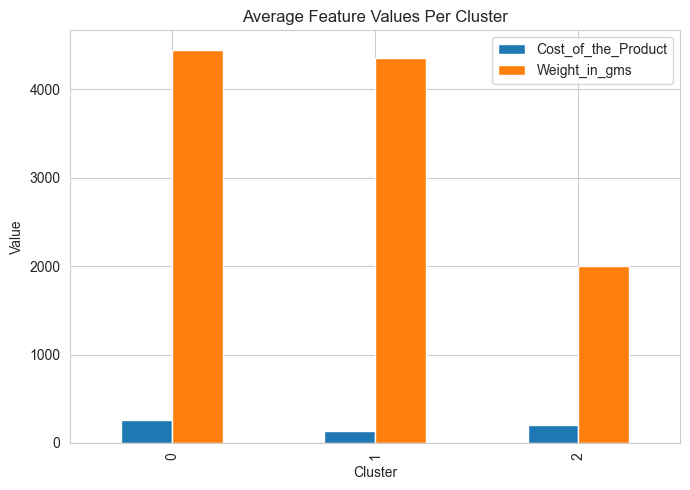

In [5]:
cluster_summary = df.groupby('Cluster')[['Cost_of_the_Product', 'Weight_in_gms']].mean()

cluster_summary.plot(kind='bar', figsize=(7, 5))
plt.title("Average Feature Values Per Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

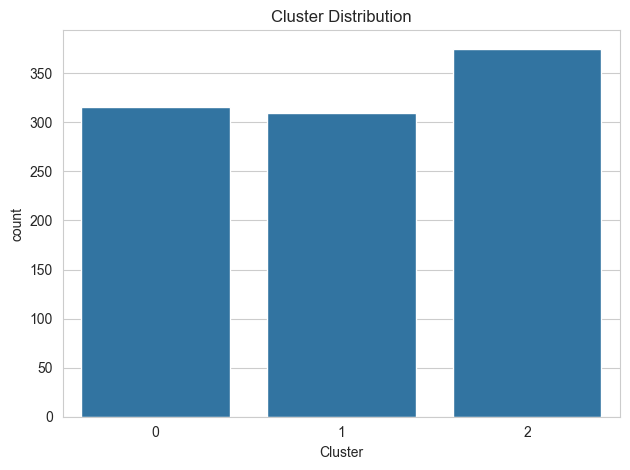

In [6]:
sns.countplot(x=df['Cluster'])
plt.title("Cluster Distribution")
plt.tight_layout()
plt.show()

In [7]:
X_features = df.drop(['Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

# Encode any remaining categorical columns
X_features = pd.get_dummies(X_features, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X_features, y)

selected_features = X_features.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)
#ANOVA F-statistic (f_classif) to rank features by how well they separate the two target classes (Reached.on.Time_Y.N).

Top 5 Features:
Index(['Weight_in_gms', 'Cluster', 'Warehouse_block_F',
       'Mode_of_Shipment_Ship', 'Product_importance_medium'],
      dtype='object')


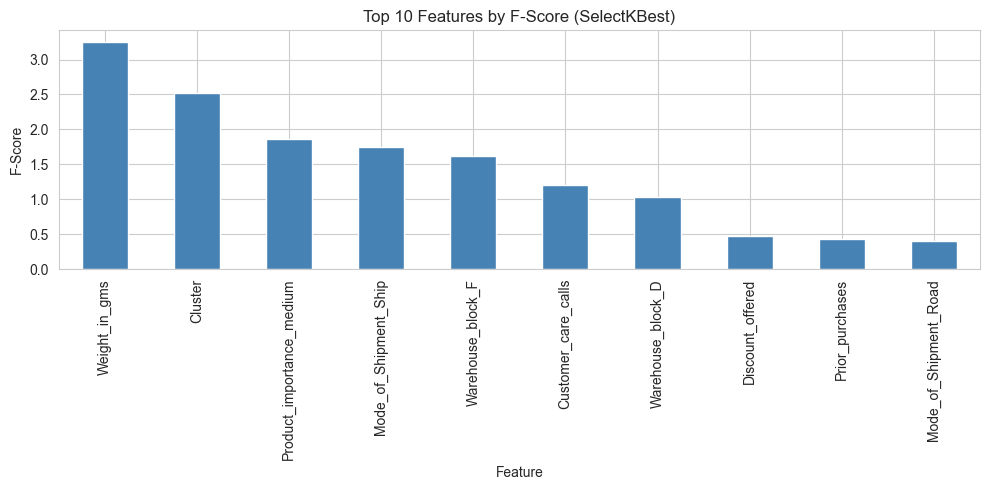

In [8]:
scores = pd.Series(selector.scores_, index=X_features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
scores.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Features by F-Score (SelectKBest)")
plt.ylabel("F-Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()